# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mhassantahir-afk/ML-Engineering-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import duckdb
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')

con = duckdb.connect()
con.sql(f"CREATE OR REPLACE SECRET hf_token (TYPE HUGGINGFACE, TOKEN '{hf_token}');")

rel = "hf://datasets/FlyRank/internship-warehouse"

In [59]:
import numpy as np

feature_frame = con.execute(f"""
    WITH daily AS (
        SELECT
            content_hash_id,
            client_hash_id,
            report_date,
            gsc_impressions,
            gsc_clicks,
            gsc_avg_position,
            CASE WHEN report_date < DATE '2026-03-16' THEN 'first_half' ELSE 'second_half' END AS period
        FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/*.parquet')
        WHERE gsc_data_available IS TRUE
    ),
    features AS (
        SELECT
            content_hash_id,
            client_hash_id,
            SUM(CASE WHEN period = 'first_half' THEN gsc_impressions ELSE 0 END) AS feat_impressions,
            SUM(CASE WHEN period='second_half' THEN gsc_impressions ELSE 0 END) AS feat_impressions_second_half,
            SUM(CASE WHEN period = 'first_half' THEN gsc_clicks ELSE 0 END) AS feat_clicks,
            AVG(CASE WHEN period = 'first_half' AND gsc_avg_position > 0 THEN gsc_avg_position END) AS position_first_half,
            AVG(CASE WHEN period = 'second_half' AND gsc_avg_position > 0 THEN gsc_avg_position END) AS position_second_half,
            SUM(CASE WHEN period = 'first_half' THEN 1 ELSE 0 END) AS feat_days_active,
            SUM(CASE WHEN period = 'first_half' THEN gsc_clicks ELSE 0 END) * 1.0
                / NULLIF(SUM(CASE WHEN period = 'first_half' THEN gsc_impressions ELSE 0 END), 0) AS feat_ctr
        FROM daily
        GROUP BY content_hash_id, client_hash_id
    ),
    label AS (
        SELECT
            content_hash_id,
            client_hash_id,
            SUM(CASE WHEN period = 'first_half' THEN gsc_impressions ELSE 0 END) AS first_half,
            SUM(CASE WHEN period = 'second_half' THEN gsc_impressions ELSE 0 END) AS second_half
        FROM daily
        GROUP BY content_hash_id, client_hash_id
    )
    SELECT
        f.content_hash_id,
        f.client_hash_id,
        f.feat_impressions,
        f.feat_impressions_second_half,
        f.feat_clicks,
        f.position_first_half,
        f.position_second_half,
        (f.position_second_half - f.position_first_half) AS position_change,
        f.feat_days_active,
        f.feat_ctr,
        CASE
            WHEN (l.second_half - l.first_half) * 1.0 / NULLIF(l.first_half, 0) * 100 <= -10
            THEN TRUE ELSE FALSE
        END AS declining_flag
    FROM features f
    JOIN label l
        ON f.content_hash_id = l.content_hash_id AND f.client_hash_id = l.client_hash_id
    WHERE l.first_half > 0
      AND f.position_first_half IS NOT NULL
      AND f.position_second_half IS NOT NULL
    ORDER BY f.content_hash_id, f.client_hash_id
""").df()

# Belt-and-suspenders: also reset the index after sorting, so row positions are fully deterministic
feature_frame = feature_frame.reset_index(drop=True)

print(feature_frame.shape)

print("\n=== Feature Frame ===")
print(feature_frame.shape)
feature_frame.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(139747, 11)

=== Feature Frame ===
(139747, 11)


,content_hash_id,client_hash_id,feat_impressions,feat_impressions_second_half,feat_clicks,position_first_half,position_second_half,position_change,feat_days_active,feat_ctr,declining_flag
0,content_000005d4ced12088,client_9958f0a7ae1df715,23.0,63.0,0.0,72.101852,73.306667,1.204815,9.0,0.000000,False
1,content_00007bd2985b77c3,client_73cda7b4e4f265ea,22.0,25.0,0.0,12.600000,6.600000,-6.000000,12.0,0.000000,False
2,content_0000cd28fbda69f3,client_3ffa76342f366962,11.0,18.0,0.0,4.062500,4.553333,0.490833,8.0,0.000000,False
3,content_00014efc121d911d,client_08a6a72ff48e62c0,53.0,63.0,0.0,6.768864,4.688095,-2.080769,14.0,0.000000,False
4,content_000184dde41afe75,client_62f4a7e64f5e0096,2405.0,2480.0,8.0,3.682934,3.477619,-0.205315,15.0,0.003326,False


In [60]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GroupShuffleSplit

feature_cols = ['feat_impressions', 'feat_clicks', 'position_first_half',
                'feat_days_active', 'feat_ctr']

X = feature_frame[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = feature_frame['declining_flag']
groups = feature_frame['client_hash_id']  # used ONLY for splitting, never as a feature

splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=4, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

rf_scores_test = rf.predict_proba(X_test)[:, 1]
rf_precision_20 = precision_at_k(rf_scores_test, y_test.values, 20)
rf_precision_50 = precision_at_k(rf_scores_test, y_test.values, 50)

print(f"Random Forest Precision@20: {rf_precision_20:.3f}")
print(f"Random Forest Precision@50: {rf_precision_50:.3f}")

Random Forest Precision@20: 0.500
Random Forest Precision@50: 0.640


In [61]:
# 1. Score the test set
# predict_proba returns [P(not declining), P(declining)]; we want column 1
proba_declining = rf.predict_proba(X_test)[:, 1]

# 2. Build the ranked queue from the test-set rows
queue = (
    feature_frame
    .iloc[test_idx]                       # back to original test rows
    .assign(
        proba_declining=proba_declining,  # model score
        queue_rank=lambda df: df['proba_declining']
                               .rank(method='first', ascending=False)
                               .astype(int)
    )
    [['queue_rank', 'content_hash_id', 'client_hash_id',
      'proba_declining', 'declining_flag',
      'feat_impressions', 'feat_clicks',
      'position_first_half', 'position_second_half',
      'position_change', 'feat_days_active', 'feat_ctr']]
    .sort_values('queue_rank')
    .reset_index(drop=True)
)

# 3. Top 20 priority pages
top_20 = queue.head(20)

print(f"Test-set size: {len(queue)}")
print(f"Declining pages in test set: {y_test.sum()}")
print("\nTop 20 priority pages:")
display(top_20)  # or just `print(top_20)` if not in a notebook

Test-set size: 11636
Declining pages in test set: 4091

Top 20 priority pages:


,queue_rank,content_hash_id,client_hash_id,proba_declining,declining_flag,feat_impressions,feat_clicks,position_first_half,position_second_half,position_change,feat_days_active,feat_ctr
0,1,content_2dc954b9ae28df53,client_e5c2aa26a8598242,0.679853,False,6951.0,8.0,55.996136,49.189093,-6.807044,15.0,0.001151
1,2,content_44c1697a4863f94f,client_e5c2aa26a8598242,0.668891,True,5065.0,5.0,46.060050,46.901165,0.841116,15.0,0.000987
2,3,content_1573eb48e6bc7c92,client_e5c2aa26a8598242,0.659754,True,8404.0,1.0,49.864153,47.431155,-2.432997,15.0,0.000119
3,4,content_459450adc5699701,client_e5c2aa26a8598242,0.657602,True,16532.0,24.0,43.093670,22.778427,-20.315244,15.0,0.001452
4,5,content_d7982b8ad5e27e6e,client_e5c2aa26a8598242,0.655422,True,6128.0,2.0,45.267575,43.108427,-2.159148,15.0,0.000326
5,6,content_8b898761780f350c,client_e5c2aa26a8598242,0.653085,True,12567.0,1.0,45.082535,50.742037,5.659501,15.0,0.000080
6,7,content_ee79d4883d6677df,client_e5c2aa26a8598242,0.650272,False,2944.0,2.0,44.729279,30.680902,-14.048377,15.0,0.000679
7,8,content_d38b667854cbd07e,client_e5c2aa26a8598242,0.648483,False,1883.0,2.0,43.626300,45.366679,1.740380,15.0,0.001062
8,9,content_3ec5a36b9d843281,client_e5c2aa26a8598242,0.648394,True,1066.0,1.0,48.401668,42.782506,-5.619162,15.0,0.000938
9,10,content_c1e4bac36f0478b9,client_e5c2aa26a8598242,0.647121,False,1914.0,4.0,45.078250,43.740324,-1.337926,15.0,0.002090


In [62]:
print((queue['proba_declining'] == 0.628886).sum())
print(np.isclose(queue['proba_declining'], 0.628886).sum())
print(queue['proba_declining'].round(6).value_counts())

print(queue.groupby('client_hash_id').size().sort_values(ascending=False).head(10))
print(f"\nTotal unique clients in test set: {queue['client_hash_id'].nunique()}")

0
0
proba_declining
0.504493    511
0.502496    221
0.491184    199
0.465663    177
0.503954    121
           ... 
0.597604      1
0.491138      1
0.490861      1
0.597771      1
0.492153      1
Name: count, Length: 4866, dtype: int64
client_hash_id
client_3f0ce4d44fe94f3d    3281
client_2094c6eb080311d5    2994
client_e5c2aa26a8598242    2634
client_1a730cb2640a1abf    1286
client_0fa64a184f18a4a0     960
client_9d54435aabd95a6c     169
client_def0955f7a377868      99
client_d211cb07b9059bab      81
client_b77d0d5f08f05e64      47
client_ccdd78843409c8c7      36
dtype: int64

Total unique clients in test set: 13


Note: here it is observed that `client_e5c2aa26a8598242` has 2634, roughly 22.7% of the total pages.

In [63]:
# Take your full ranked queue (not just top 20), split into "high confidence" vs "rest"
high_conf = queue[queue['proba_declining'] >= queue['proba_declining'].quantile(0.9)]  # top 10% by confidence
rest = queue[queue['proba_declining'] < queue['proba_declining'].quantile(0.9)]

print("High-confidence predicted-declining pages:")
print(high_conf[['feat_impressions', 'feat_clicks', 'feat_days_active', 'position_first_half',
                  'position_change', 'feat_ctr']].describe())

print("\nRest of the queue:")
print(rest[['feat_impressions', 'feat_clicks', 'feat_days_active', 'position_first_half',
             'position_change', 'feat_ctr']].describe())

High-confidence predicted-declining pages:
       feat_impressions  feat_clicks  feat_days_active  position_first_half  \
count       1164.000000  1164.000000       1164.000000          1164.000000   
mean        1050.950172     0.765464         14.974227            13.948332   
std         1844.066016     2.455620          0.158526            11.336021   
min          186.000000     0.000000         14.000000             0.745870   
25%          311.000000     0.000000         15.000000             5.700561   
50%          545.000000     0.000000         15.000000             9.064042   
75%         1060.000000     1.000000         15.000000            20.629191   
max        25042.000000    36.000000         15.000000            64.872355   

       position_change     feat_ctr  
count      1164.000000  1164.000000  
mean          3.276793     0.000374  
std           7.327358     0.000657  
min         -29.642462     0.000000  
25%          -0.194578     0.000000  
50%           1.9

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Reason Codes:**

1. `near_zero_ctr` Pages the model ranked as declining with high confidence showed a CTR averaging 0.000374, roughly 14x lower than the rest of the queue (0.005375). Triggered when a page's CTR falls below approximately 0.001, just above the high-confidence group's 75th percentile (0.000702), and well below the rest of the queue's 75th percentile (0.005546).

2. `weak_absolute_position` Pages the model ranked as declining with high confidence had a median first-half position of 9.06, notably weaker than the rest of the queue's median of 7.50. Triggered when a page's position_first_half exceeds approximately 10 (outside typical "page 1" search results).

the CTR threshold shows a clear separation between groups; the position threshold is more marginal and should be treated as a softer signal.

Both reason codes are meaningful specifically in the context of the ranked queue, which already surfaces pages with real traffic (high impressions) they are not intended as standalone rules for arbitrary, low-traffic pages. A page may carry both reason codes at once if it meets both conditions; this is expected and reflects a page with multiple concerning signals, not an error.

**Actions:** `review` For this ML task, both reason codes lead to the same instruction to the reviewer: open the page and assess it manually. The model does not prescribe a specific fix (rewrite, expand, etc.), since that requires human judgment the available features cannot determine.

In [64]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

playbook_queue = queue.copy()

# Reason code conditions, using the thresholds established above
playbook_queue['near_zero_ctr'] = playbook_queue['feat_ctr'] < 0.001
playbook_queue['weak_absolute_position'] = playbook_queue['position_first_half'] > 10

# Combine into a single reason_codes column (list of triggered codes per page)
def get_reason_codes(row):
    codes = []
    if row['near_zero_ctr']:
        codes.append('near_zero_ctr')
    if row['weak_absolute_position']:
        codes.append('weak_absolute_position')
    return codes

playbook_queue['reason_codes'] = playbook_queue.apply(get_reason_codes, axis=1)

# Action: review if flagged with at least one reason code, otherwise no action needed
playbook_queue['action'] = playbook_queue['reason_codes'].apply(
    lambda codes: 'review' if len(codes) > 0 else 'none'
)

# Filter to only flagged pages, take top 50 by rank
playbook_final = playbook_queue[playbook_queue['action'] == 'review'].copy()
playbook_final = playbook_final.sort_values('queue_rank').head(50).reset_index(drop=True)

# Convert reason_codes list into a clean, readable string instead of a Python list
playbook_final['reason_codes'] = playbook_final['reason_codes'].apply(lambda codes: ', '.join(codes))

# Rename columns for reviewer-facing clarity
playbook_final = playbook_final.rename(columns={
    'queue_rank': 'rank',
    'content_hash_id': 'page_id',
    'client_hash_id': 'client_id',
    'proba_declining': 'confidence',
    'feat_ctr': 'ctr',
    'position_first_half': 'position'
})

playbook_final = playbook_final[[
    'rank', 'page_id', 'client_id', 'confidence',
    'reason_codes', 'action', 'ctr', 'position'
]]

print(playbook_final.shape)
playbook_final.head(20)


(50, 8)


,rank,page_id,client_id,confidence,reason_codes,action,ctr,position
0,1,content_2dc954b9ae28df53,client_e5c2aa26a8598242,0.679853,weak_absolute_position,review,0.001151,55.996136
1,2,content_44c1697a4863f94f,client_e5c2aa26a8598242,0.668891,"near_zero_ctr, weak_absolute_position",review,0.000987,46.060050
2,3,content_1573eb48e6bc7c92,client_e5c2aa26a8598242,0.659754,"near_zero_ctr, weak_absolute_position",review,0.000119,49.864153
3,4,content_459450adc5699701,client_e5c2aa26a8598242,0.657602,weak_absolute_position,review,0.001452,43.093670
4,5,content_d7982b8ad5e27e6e,client_e5c2aa26a8598242,0.655422,"near_zero_ctr, weak_absolute_position",review,0.000326,45.267575
5,6,content_8b898761780f350c,client_e5c2aa26a8598242,0.653085,"near_zero_ctr, weak_absolute_position",review,0.000080,45.082535
6,7,content_ee79d4883d6677df,client_e5c2aa26a8598242,0.650272,"near_zero_ctr, weak_absolute_position",review,0.000679,44.729279
7,8,content_d38b667854cbd07e,client_e5c2aa26a8598242,0.648483,weak_absolute_position,review,0.001062,43.626300
8,9,content_3ec5a36b9d843281,client_e5c2aa26a8598242,0.648394,"near_zero_ctr, weak_absolute_position",review,0.000938,48.401668
9,10,content_c1e4bac36f0478b9,client_e5c2aa26a8598242,0.647121,weak_absolute_position,review,0.002090,45.078250


In [65]:
import os

# Define project_root assuming it's two levels up from the notebook's directory
#project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

# Ensure output directories exist
outputs_dir = os.path.join("ML-Engineering-Internship", "work", "outputs")
os.makedirs(outputs_dir, exist_ok=True)

# Export the ranked queue CSV
queue_output_path = os.path.join(outputs_dir, "content_action_playbook.csv")
playbook_final.to_csv(queue_output_path, index=False)

print(f"Saved {len(playbook_final)} rows to {queue_output_path}")

Saved 50 rows to ML-Engineering-Internship/work/outputs/content_action_playbook.csv


In [66]:
import json

metrics = {
    "model": "Random Forest (max_depth=4, n_estimators=200)",
    "split": "client-grouped, test_size=0.3",
    "precision_at_50_grouped": 0.64,  # replace with your actual locked-in number
    "baseline_precision_at_50": 0.30,  # replace with your actual locked-in number
    "base_rate": 0.351581,  # replace with your actual locked-in number
    "reason_code_thresholds": {
        "near_zero_ctr": "ctr < 0.001",
        "weak_absolute_position": "position_first_half > 10"
    },
    "queue_size": len(playbook_final)
}

metrics_output_path = os.path.join(outputs_dir, "playbook_metrics.json")
with open(metrics_output_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Saved metrics to {metrics_output_path}")

Saved metrics to ML-Engineering-Internship/work/outputs/playbook_metrics.json


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended Use:**

This tool is intended for a content writer / SEO strategist, or anyone responsible for triaging a large content inventory who needs help deciding which pages to review first. The tool gives a list of pages ranked on more likely to be declining. The output of the tool is strictly decision support, it tell which order to review the declining pages, it does not indicate what to fix and how, a human reviewer will be making the final call on each page.

**Limits:**



*   `declining_flag` is a proxy label defined by the threshold -10% drop in impressions from the first half to the second half of the month. It is not the ground truth label and is not a true observed future outcome.
*   The comparison and feature set of the model is built upon the data collected from  one month `2026-03`, results may not generalize on other months or season specific patterns.
*   client sizes are highly uneven (one client alone is 18% of rows); GSC/GA4 availability was only 36.7%/4.2% in this slice.
*   Precision@50 varies meaningfully depending on which split is used: 0.64 on the honest, client-grouped split versus 0.86 on a random split, a gap attributable to client-specific memorization under random splitting (see ML-09 validation audit).
*   Client tenure varies (clients joined FlyRank at different times), which may contribute to newer pages appearing to underperform simply due to less accumulated impression/click history, this hypothesis was not directly tested in this analysis and should be treated as a possible confounder, not a confirmed finding.
*   The playbook identifies pages worth reviewing; it does not claim refreshing them will cause recovery.
*   The top of the ranked queue was dominated by a single client (client_e5c2aa26a8598242), disproportionate to its share of the test set (22.7%); the model's confidence may not generalize evenly across all clients.

In [67]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Human Review Rules:**

*   Every flagged page requires a human to actually open and assess it the model produces a candidate list, not a verdict.
*   The reason codes `near_zero_ctr`, `weak_absolute_position` are hints for where to look, not diagnoses a reviewer should verify the underlying issue actually looks real before acting.
*   The reviewer should treat the model's output as Prioritized starting point and not a verdict, always open and verify the page.
*   Given the client-concentration finding, a reviewer (or whoever manages the queue) should be aware the current queue may skew toward one client and should sanity-check that pages from underrepresented clients aren't being systematically ignored.
*   It is important to verify the underlying split that produced the results before trusting it, Precision@50 varies meaningfully depending upon the split that the model was evaluated on.

**The no-go List:**


*   No Automatic Content Changes, rewrite or deletions based upon the model's predictions. A human reviewer needs to be involved.
*   No treating `weak_absolute_position` as equally strong evidence as `near_zero_ctr`. It is already observed that the CTR threshold shows a clear separation between groups; the position threshold is more marginal and should be treated as a softer signal.
*   No using this model/queue to make claims about causing a decline or guaranteeing a fix will cause recovery.
*   No applying this queue's logic to other months, other clients' onboarding periods, or any data outside the `2026-03` scope without re-validation.
*   Reviews should not be limited to a single client's pages just because the client dominates the top of the ranking. Every client's inventory needs periodic reviews.


In [68]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*



*   **Precision drift on new months**. This model is trained entirely on data from the `month=2026-03`, if precision@50 measured on a new month's data drops meaningfully below your locked baseline (0.64), that's a clear signal something has shifted (seasonality, algorithm changes, data quality) and retraining/revalidation is due. **Trigger:** Retrain and re-evaluate the model on data from newer, more recent months.
*   **Base rate shift.** The overall decline rate observed in this slice was ~0.30-0.35 depending on the label threshold used. If a new month's natural decline rate moves substantially away from this range, the model's calibration may no longer be appropriate. **Trigger:** Recompute the base rate on new data and compare against the locked value before trusting precision numbers.
*   **Client concentration recurring**. If future queues continue to be dominated by the same single client, or a new client, this pattern is worth monitoring, it might indicate that the model is underrepresenting non-dominant clients. **Trigger:** Retrain and Evaluate model on a more balanced client representation, or add client-level normalization.
*   **Feature availability drift**. Given GSC availability was only 36.7% and GA4 only 4.2% in this slice. if these percentages shift substantially in future months (e.g., more clients get GA4 connected), the future label for the features might not produce similar results. **Trigger:** Re-check feature availability rates on new data; retrain if the composition has shifted meaningfully.


In [69]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [70]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import matplotlib.pyplot as plt
import os

figures_dir = os.path.join("work", "figures")
os.makedirs(figures_dir, exist_ok=True)

plt.style.use('default')

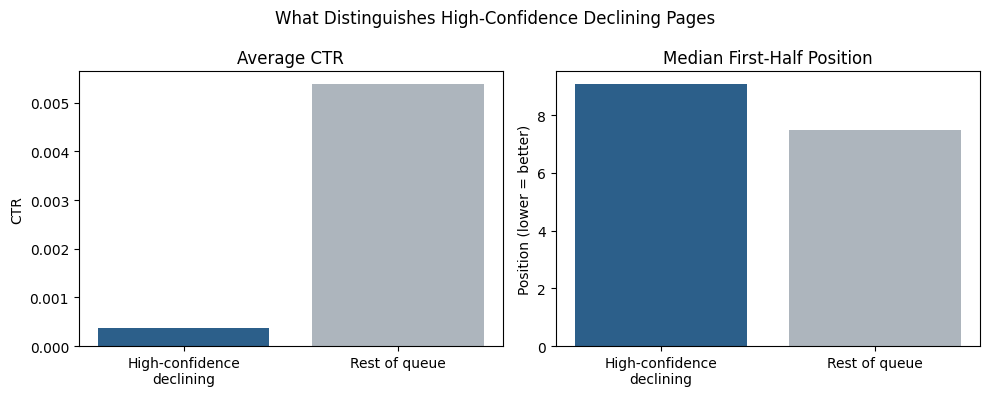

Saved to work/figures/reason_code_evidence.png


In [71]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# CTR comparison
axes[0].bar(['High-confidence\ndeclining', 'Rest of queue'],
            [high_conf['feat_ctr'].mean(), rest['feat_ctr'].mean()],
            color=['#2c5f8a', '#adb5bd'])
axes[0].set_title('Average CTR')
axes[0].set_ylabel('CTR')

# Position comparison
axes[1].bar(['High-confidence\ndeclining', 'Rest of queue'],
            [high_conf['position_first_half'].median(), rest['position_first_half'].median()],
            color=['#2c5f8a', '#adb5bd'])
axes[1].set_title('Median First-Half Position')
axes[1].set_ylabel('Position (lower = better)')

plt.suptitle('What Distinguishes High-Confidence Declining Pages')
plt.tight_layout()

fig1_path = os.path.join(figures_dir, "reason_code_evidence.png")
plt.savefig(fig1_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {fig1_path}")

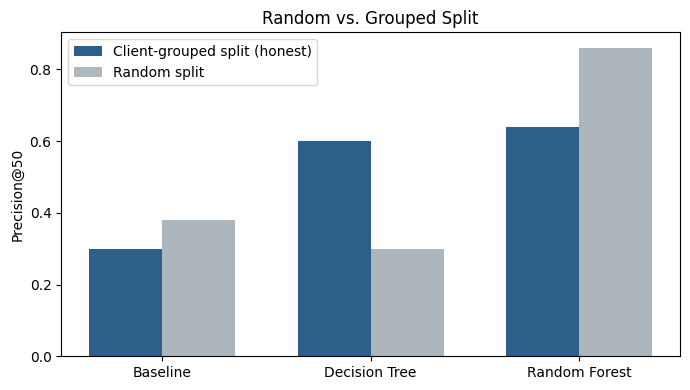

Saved to work/figures/split_comparison.png


In [72]:
fig, ax = plt.subplots(figsize=(7, 4))

methods = ['Baseline', 'Decision Tree', 'Random Forest']
grouped_scores = [0.30, 0.60, 0.64]   # replace with your final locked -20% or -10% numbers
random_scores = [0.38, 0.30, 0.86]    # replace with your final locked numbers

x = range(len(methods))
width = 0.35

ax.bar([i - width/2 for i in x], grouped_scores, width, label='Client-grouped split (honest)', color='#2c5f8a')
ax.bar([i + width/2 for i in x], random_scores, width, label='Random split', color='#adb5bd')

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel('Precision@50')
ax.set_title('Random vs. Grouped Split')
ax.legend()

plt.tight_layout()

fig2_path = os.path.join(figures_dir, "split_comparison.png")
plt.savefig(fig2_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {fig2_path}")

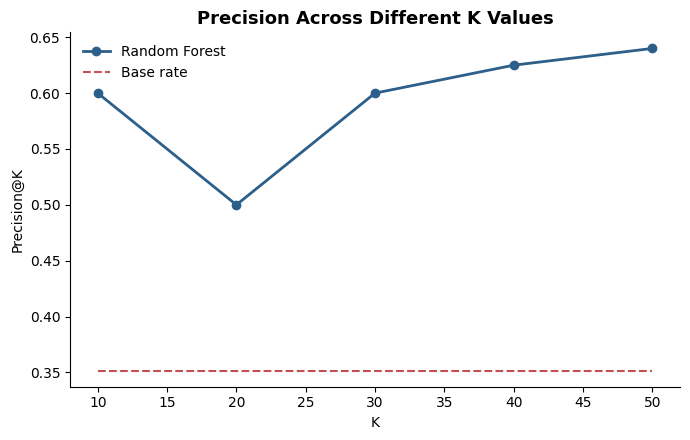

In [73]:
k_range = [10, 20, 30, 40, 50]

#baseline_curve = [precision_at_k(baseline_score_test, y_test.values, k) for k in k_range]
rf_curve = [precision_at_k(rf_scores_test, y_test.values, k) for k in k_range]
base_rate_line = [y_test.mean()] * len(k_range)

fig, ax = plt.subplots(figsize=(7, 4.5))
#ax.plot(k_range, baseline_curve, marker='o', label='Baseline rule', color='#adb5bd', linewidth=2)
ax.plot(k_range, rf_curve, marker='o', label='Random Forest', color='#2c5f8a', linewidth=2)
ax.plot(k_range, base_rate_line, linestyle='--', label='Base rate', color='#c44e52', linewidth=1.5)

ax.set_xlabel('K')
ax.set_ylabel('Precision@K')
ax.set_title('Precision Across Different K Values', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()

fig4_path = os.path.join(figures_dir, "precision_at_k_curve.png")
plt.savefig(fig4_path, dpi=150, bbox_inches='tight')
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.